# Assignment 5 - Perceptron
MATH-CSCI 485

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Load Data

In [ ]:
data=pd.read_csv('data.csv',header=None,names=['x1','x2','label'])
data.head()

In [ ]:
X=data[['x1','x2']].values
y=data['label'].values
plt.figure(figsize=(8,6))
plt.scatter(X[y==0][:,0],X[y==0][:,1],c='red',marker='o',label='Class 0',s=50)
plt.scatter(X[y==1][:,0],X[y==1][:,1],c='blue',marker='o',label='Class 1',s=50)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data Distribution')
plt.legend()
plt.savefig('data_distribution.png',bbox_inches='tight')
plt.show()

## Part 1: Heuristic Approach

In [42]:
class HeuristicPerceptron:
    def __init__(self,lr=0.01,max_iter=100):
        self.lr=lr
        self.max_iter=max_iter
        self.weights=None
        self.bias=None
        self.w_history=[]
        self.b_history=[]

    def step_function(self,z):
        return np.where(z>=0,1,0)
    def predict(self,X):
        z=np.dot(X,self.weights)+self.bias
        return self.step_function(z)
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.weights=np.random.randn(n_features)*0.1
        self.bias=np.random.randn()*0.1
        self.w_history.append(self.weights.copy())
        self.b_history.append(self.bias)
        
        for iteration in range(self.max_iter):
            errors=0
            for i in range(n_samples):
                xi=X[i]
                yi=y[i]
                z=np.dot(xi,self.weights)+self.bias
                pred=self.step_function(z)
                if pred!=yi:
                    errors+=1
                    if pred==0:
                        self.bias+=self.lr
                        self.weights+=self.lr*xi
                    else:
                        self.bias-=self.lr
                        self.weights-=self.lr*xi 
            self.w_history.append(self.weights.copy())
            self.b_history.append(self.bias)
            if errors==0:
                break
        return self

In [43]:
def plot_part1(X,y,model,title,filename=None):
    plt.figure(figsize=(10,8))
    plt.scatter(X[y==0][:,0],X[y==0][:,1],c='red',marker='o',label='Class 0',s=50)
    plt.scatter(X[y==1][:,0],X[y==1][:,1],c='blue',marker='o',label='Class 1',s=50)
    
    x_min,x_max=X[:,0].min()-0.1,X[:,0].max()+0.1
    x_vals=np.array([x_min,x_max])
    
    w=model.w_history[0]
    b=model.b_history[0]
    if w[1]!=0:
        y_vals=-(w[0]*x_vals+b)/w[1]
        plt.plot(x_vals,y_vals,'r-',linewidth=2,label='Initial')
    
    for i in range(1,len(model.w_history)-1):
        w=model.w_history[i]
        b=model.b_history[i]
        if w[1]!=0:
            y_vals=-(w[0]*x_vals+b)/w[1]
            if i==1:
                plt.plot(x_vals,y_vals,'g--',linewidth=1,alpha=0.5,label='Intermediate')
            else:
                plt.plot(x_vals,y_vals,'g--',linewidth=1,alpha=0.5)
    
    w=model.w_history[-1]
    b=model.b_history[-1]
    if w[1]!=0:
        y_vals=-(w[0]*x_vals+b)/w[1]
        plt.plot(x_vals,y_vals,'k-',linewidth=2.5,label='Final')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    if filename:
        plt.savefig(filename,bbox_inches='tight')
    plt.show()

Accuracy: 91.0%


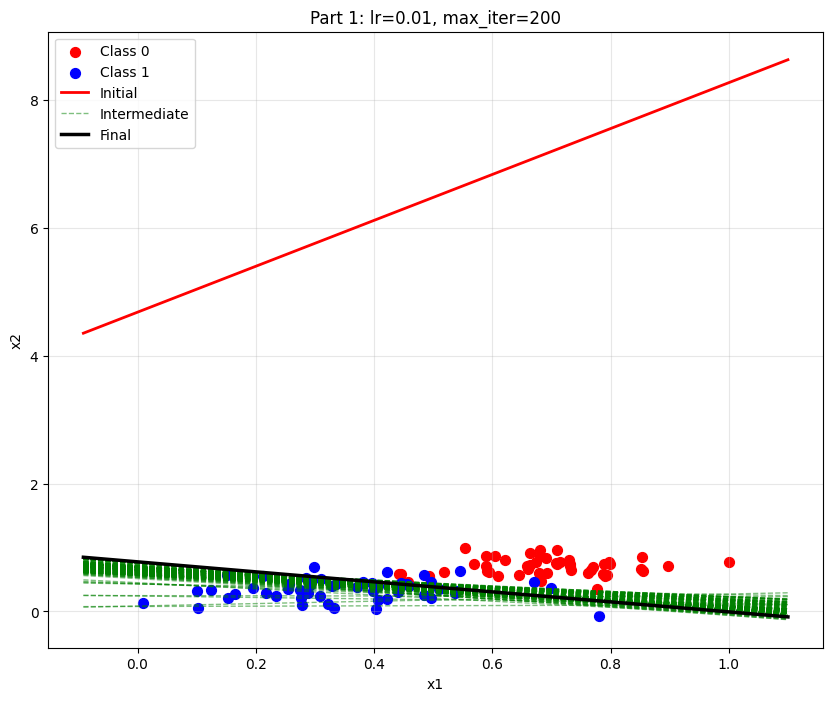

In [44]:
model1=HeuristicPerceptron(lr=0.01,max_iter=200)
model1.fit(X,y)
print(f'Accuracy: {np.mean(model1.predict(X)==y)*100:.1f}%')
plot_part1(X,y,model1,'Part 1: lr=0.01, max_iter=200','part1_lr0.01.png')

Accuracy: 93.0%


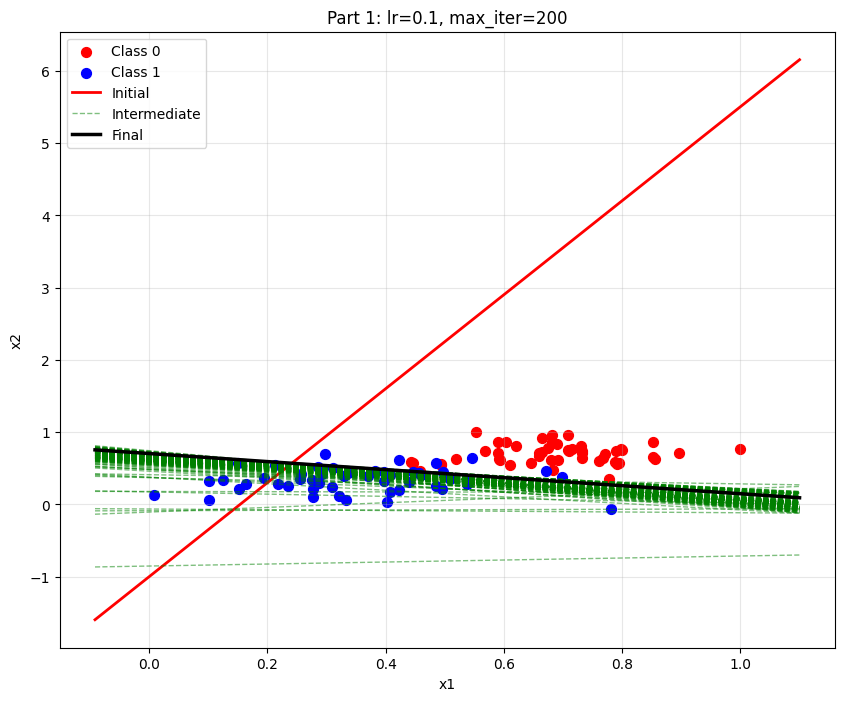

In [45]:
model2=HeuristicPerceptron(lr=0.1,max_iter=200)
model2.fit(X,y)
print(f'Accuracy: {np.mean(model2.predict(X)==y)*100:.1f}%')
plot_part1(X,y,model2,'Part 1: lr=0.1, max_iter=200','part1_lr0.1.png')

Accuracy: 91.0%


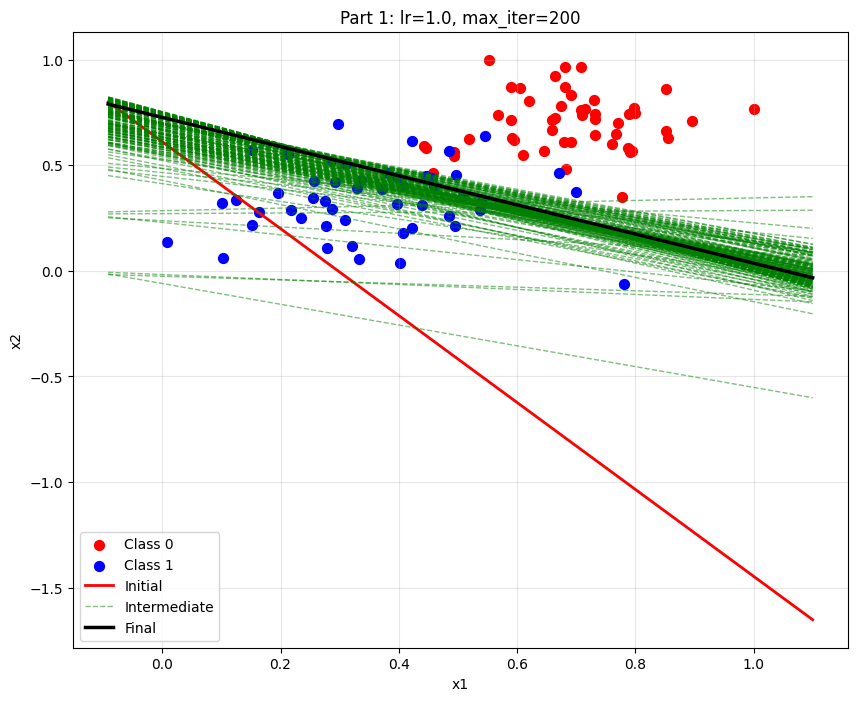

In [46]:
model3=HeuristicPerceptron(lr=1.0,max_iter=200)
model3.fit(X,y)
print(f'Accuracy: {np.mean(model3.predict(X)==y)*100:.1f}%')
plot_part1(X,y,model3,'Part 1: lr=1.0, max_iter=200','part1_lr1.0.png')

## Part 2: Gradient Descent with Sigmoid

In [48]:
class GradientDescentPerceptron:
    def __init__(self,lr=0.1,epochs=100):
        self.lr=lr
        self.epochs=epochs
        self.weights=None
        self.bias=None
        self.w_history=[]
        self.b_history=[]
        self.losses=[]
        self.loss_epochs=[]
        
    def sigmoid(self,z):
        z=np.clip(z,-500,500)
        return 1/(1+np.exp(-z))
    
    def log_loss(self,y_true,y_pred):
        eps=1e-15
        y_pred=np.clip(y_pred,eps,1-eps)
        return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))
    
    def predict_proba(self,X):
        z=np.dot(X,self.weights)+self.bias
        return self.sigmoid(z)
    
    def predict(self,X):
        return (self.predict_proba(X)>=0.5).astype(int)
    
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.weights=np.random.randn(n_features)*0.1
        self.bias=np.random.randn()*0.1
        self.w_history.append(self.weights.copy())
        self.b_history.append(self.bias)
        for epoch in range(self.epochs):
            for i in range(n_samples):
                xi=X[i]
                yi=y[i]
                z=np.dot(xi,self.weights)+self.bias
                y_pred=self.sigmoid(z)
                error=yi-y_pred
                self.bias+=self.lr*error
                self.weights+=self.lr*error*xi
            self.w_history.append(self.weights.copy())
            self.b_history.append(self.bias)
            if epoch%10==0 or epoch==self.epochs-1:
                y_pred_all=self.predict_proba(X)
                loss=self.log_loss(y,y_pred_all)
                self.losses.append(loss)
                self.loss_epochs.append(epoch)
        
        return self

In [49]:
def plot_part2(X,y,model,title,filename=None):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
    ax1.scatter(X[y==0][:,0],X[y==0][:,1],c='red',marker='o',label='Class 0',s=50)
    ax1.scatter(X[y==1][:,0],X[y==1][:,1],c='blue',marker='o',label='Class 1',s=50)
    x_min,x_max=X[:,0].min()-0.1,X[:,0].max()+0.1
    x_vals=np.array([x_min,x_max])
    w=model.w_history[0]
    b=model.b_history[0]
    if w[1]!=0:
        y_vals=-(w[0]*x_vals+b)/w[1]
        ax1.plot(x_vals,y_vals,'r-',linewidth=2,label='Initial')    
    step=max(1,len(model.w_history)//20)
    for i in range(1,len(model.w_history)-1,step):
        w=model.w_history[i]
        b=model.b_history[i]
        if w[1]!=0:
            y_vals=-(w[0]*x_vals+b)/w[1]
            if i==1:
                ax1.plot(x_vals,y_vals,'g--',linewidth=1,alpha=0.5,label='Intermediate')
            else:
                ax1.plot(x_vals,y_vals,'g--',linewidth=1,alpha=0.5)
    
    w=model.w_history[-1]
    b=model.b_history[-1]
    if w[1]!=0:
        y_vals=-(w[0]*x_vals+b)/w[1]
        ax1.plot(x_vals,y_vals,'k-',linewidth=2.5,label='Final')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    ax1.set_title('Solution boundary')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax2.plot(model.loss_epochs,model.losses,'b-',linewidth=2)
    ax2.set_xlabel('Number of epochs')
    ax2.set_ylabel('error')
    ax2.set_title('Error Plot')
    ax2.grid(alpha=0.3)
    plt.suptitle(title)
    plt.tight_layout()
    if filename:
        plt.savefig(filename,bbox_inches='tight')
    plt.show()

Accuracy: 93.0%


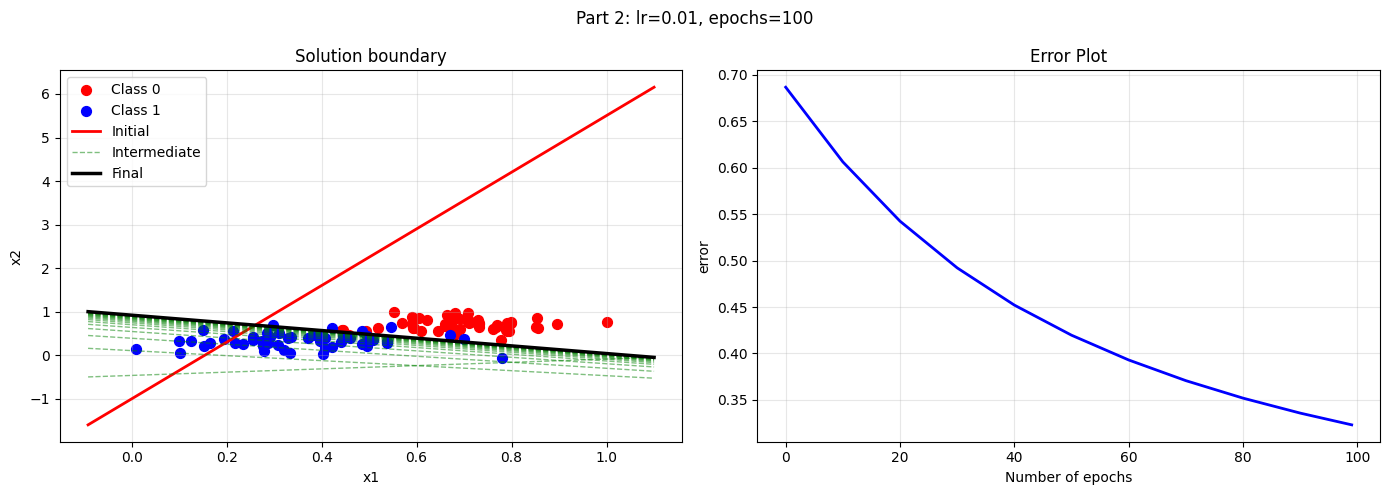

In [50]:
model4=GradientDescentPerceptron(lr=0.01,epochs=100)
model4.fit(X,y)
print(f'Accuracy: {np.mean(model4.predict(X)==y)*100:.1f}%')
plot_part2(X,y,model4,'Part 2: lr=0.01, epochs=100','part2_lr0.01_e100.png')

Accuracy: 93.0%


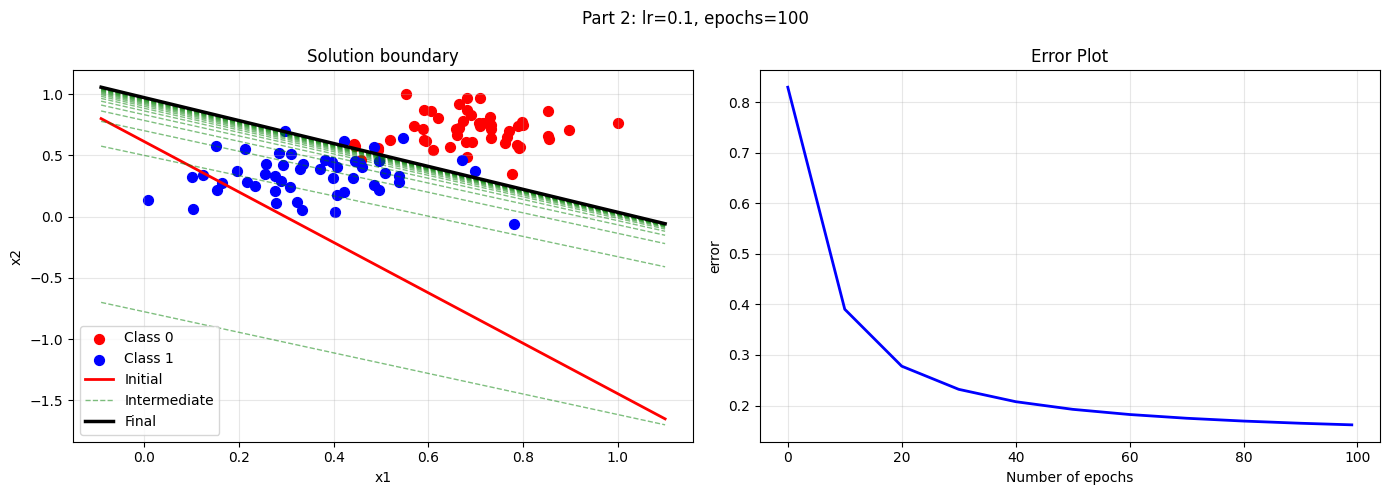

In [51]:
model5=GradientDescentPerceptron(lr=0.1,epochs=100)
model5.fit(X,y)
print(f'Accuracy: {np.mean(model5.predict(X)==y)*100:.1f}%')
plot_part2(X,y,model5,'Part 2: lr=0.1, epochs=100','part2_lr0.1_e100.png')

Accuracy: 94.0%


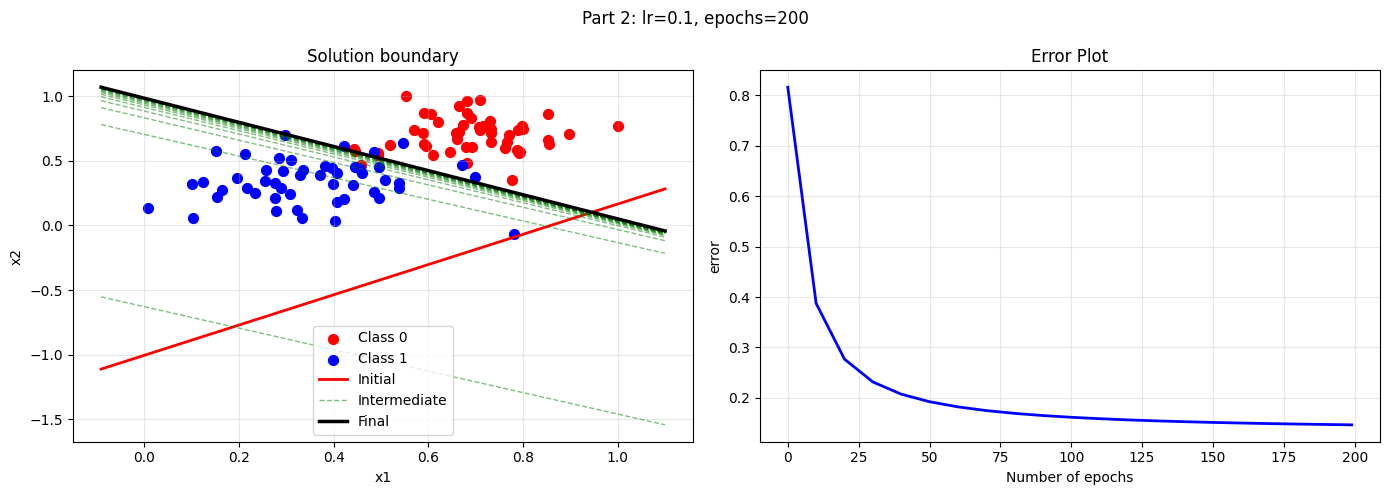

In [52]:
model6=GradientDescentPerceptron(lr=0.1,epochs=200)
model6.fit(X,y)
print(f'Accuracy: {np.mean(model6.predict(X)==y)*100:.1f}%')
plot_part2(X,y,model6,'Part 2: lr=0.1, epochs=200','part2_lr0.1_e200.png')

Accuracy: 93.0%


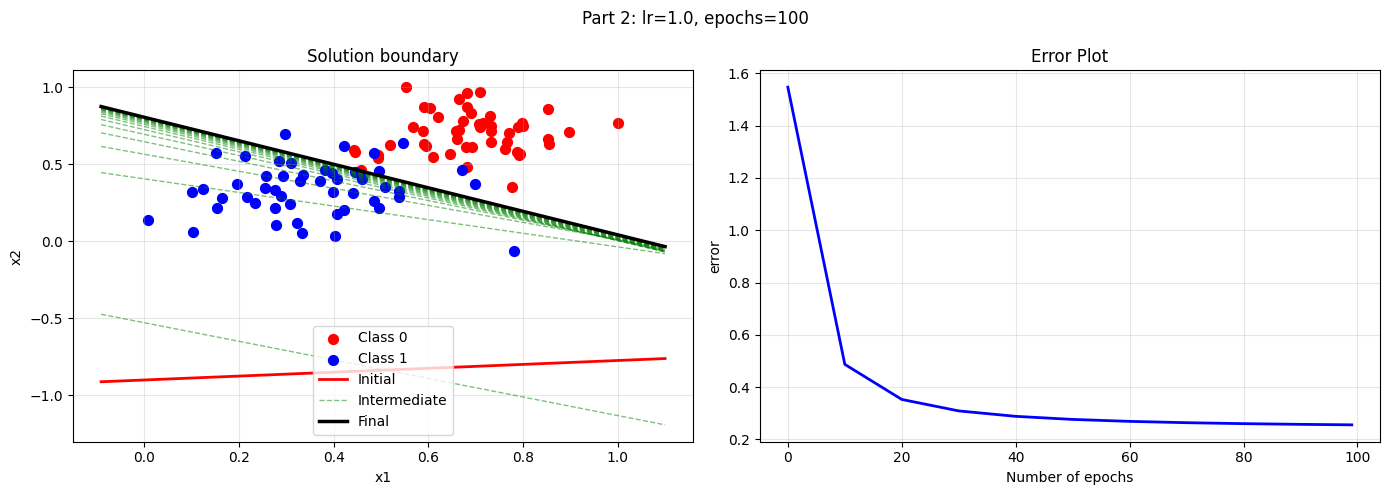

In [53]:
model7=GradientDescentPerceptron(lr=1.0,epochs=100)
model7.fit(X,y)
print(f'Accuracy: {np.mean(model7.predict(X)==y)*100:.1f}%')
plot_part2(X,y,model7,'Part 2: lr=1.0, epochs=100','part2_lr1.0_e100.png')